# Proposed Model — CEDAR Split Evaluation

DenseNet-121 + CBAM (post-block / pre-transition) trained in two steps:

| Step | Method | Epochs |
|---|---|---|
| 1 — Pretraining | TripletLoss (Euclidean, hard-negative mining) | 30 |
| 2 — Meta-training | Episodic 1-shot verification + BCEWithLogitsLoss | 70 |

Combined total = **100 epochs**, matching the baseline budget exactly.

| | |
|---|---|
| **Dataset** | CEDAR |
| **Split** | 70:15:15 |

**Prerequisite:** run `scripts/prepare_split_ratios.py` to generate split JSONs.

## Step 1 — Imports & Reproducibility

In [1]:
import os, sys, json, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.manifold import TSNE
import seaborn as sns

# ── Repo root ─────────────────────────────────────────────────────────────────
REPO_ROOT = os.path.abspath(os.path.join(os.path.abspath(os.getcwd()), '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# ── Custom modules ────────────────────────────────────────────────────────────
from models.feature_extractor                  import DenseNetFeatureExtractor
from models.meta_learner                       import MetricGenerator
from models.Triplet_Siamese_Similarity_Network import tDCBAM
from losses.triplet_loss                       import TripletLoss
from utils.model_evaluation                    import (compute_metrics, _plot_det_curve,
                                                        _plot_far_frr, _plot_confusion_matrix,
                                                        _plot_score_distribution, _plot_roc_curve)
from dataloader.tDCBAM_trainloader import get_transforms, sample_augment_params, preprocess_image


# ── Reproducibility ───────────────────────────────────────────────────────────
def seed_everything(seed=42):
    """Seed all random sources for full reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f" > [Seed] {seed}")

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [Device] {DEVICE}" +
      (f"  ({torch.cuda.get_device_name()})" if torch.cuda.is_available() else ""))


/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [Seed] 42
 > [Device] cuda  (NVIDIA GeForce RTX 5080)


## Step 2 — Configuration

In [2]:
# ── Identity ──────────────────────────────────────────────────────────────────
NOTEBOOK_NAME = 'proposed_cedar'
DATASET       = 'cedar'
DATASET_NAME  = 'CEDAR'

# ── Paths ─────────────────────────────────────────────────────────────────────
SPLIT_DIR      = os.path.join(REPO_ROOT, 'data',        'ratio_splits')
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'proposed_splits')
EVAL_DIR       = os.path.join(REPO_ROOT, 'model_evals',  NOTEBOOK_NAME)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,       exist_ok=True)

# ── Split ratios ──────────────────────────────────────────────────────────────
SPLIT_RATIOS = ['70_15_15']

# ── Data ──────────────────────────────────────────────────────────────────────
IMG_SIZE    = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE)
NUM_WORKERS = 4

# ── Step 1: Pretraining hyperparameters (30 epochs) ───────────────────────────
PRETRAIN_EPOCHS        = 30
PRETRAIN_PHASE1_EPOCHS = 0
PRETRAIN_LR            = 1e-4
PRETRAIN_MARGIN        = 0.2
PRETRAIN_BATCH_SIZE    = 32

# ── Step 2: Meta-training hyperparameters (70 epochs) ─────────────────────────
META_EPOCHS        = 70
META_PHASE1_EPOCHS = 20
META_LR_PHASE1     = 1e-3
META_LR_BACKBONE   = 1e-5
META_LR_HEAD       = 2e-4
META_WEIGHT_DECAY  = 1e-2
META_BATCH_SIZE    = 16

# ── Episodic protocol ─────────────────────────────────────────────────────────
K_SHOT          = 1
N_QUERY_GENUINE = 1
N_QUERY_FORGERY = 1

# ── Model dimensions ──────────────────────────────────────────────────────────
FEATURE_DIM   = 1024   # DenseNetFeatureExtractor output
EMBEDDING_DIM = 1024   # MetricGenerator input (2 × FEATURE_DIM)

print(f" > [Config] {DATASET_NAME} | Splits: {SPLIT_RATIOS}")
print(f" > [Config] Pretrain: {PRETRAIN_EPOCHS} ep "
      f"(P1 frozen: {PRETRAIN_PHASE1_EPOCHS}) | margin={PRETRAIN_MARGIN}")
print(f" > [Config] Meta:     {META_EPOCHS} ep "
      f"(P1 frozen: {META_PHASE1_EPOCHS}) | K={K_SHOT}")
print(f" > [Config] Total: {PRETRAIN_EPOCHS + META_EPOCHS} epochs | "
      f"WD: {META_WEIGHT_DECAY} | Checkpoints: {CHECKPOINT_DIR}")


 > [Config] CEDAR | Splits: ['70_15_15']
 > [Config] Pretrain: 30 ep (P1 frozen: 0) | margin=0.2
 > [Config] Meta:     70 ep (P1 frozen: 20) | K=1
 > [Config] Total: 100 epochs | WD: 0.01 | Checkpoints: /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits


## Step 3 — Transforms

> This cell is **verbatim identical** in both the baseline and the proposed notebook. Any change here must be mirrored in the other notebook.

In [3]:
# ── Transform factory ─────────────────────────────────────────────────────────
train_transform = get_transforms(mode='train', input_shape=INPUT_SHAPE)
val_transform   = get_transforms(mode='val',   input_shape=INPUT_SHAPE)

print(" > [Transforms] train_transform: augmentation ON  (geometric)")
print(" > [Transforms] val_transform  : augmentation OFF (preprocessing only)")


 > [Transforms] train_transform: augmentation ON  (geometric)
 > [Transforms] val_transform  : augmentation OFF (preprocessing only)


## Step 4 — Datasets

Two dataset classes are required by the proposed two-step training procedure:

| Class | Used in | Returns |
|---|---|---|
| `SplitTripletDataset` | Step 1 pretraining | (anchor, positive, negative, dummy_label) |
| `SplitEpisodicDataset` | Step 2 meta-training | {support_images, query_images, query_labels} |

In [4]:
class SplitTripletDataset(Dataset):
    """
    Triplet dataset for Step 1 pretraining.

    Generates (Anchor, Positive, Negative) triplets with hard negative mining:
        70 % of negatives are skilled forgeries from the same writer (hard).
        30 % are genuine signatures from a randomly chosen other writer (easy).

    Triplets are regenerated each epoch via _generate_triplets() to prevent
    the model from memorising fixed pairings across epochs.

    Augmentation mode is controlled by the `training` flag:
        training=True  → triplet-level augmentation (proposed pipeline).
                         sample_augment_params() is called ONCE per __getitem__
                         and the same flip/rotation/scale/translation is applied
                         to all three images.  This prevents the model from
                         seeing orientation-mismatched anchor-positive pairs.
        training=False → val_transform is applied per-image (no augmentation).

    Args:
        user_dict    (dict)     : {uid: {'genuine': [...paths], 'forged': [...paths]}}
        input_shape  (tuple)    : Canvas size for preprocess_image. Default (224, 224).
        val_transform(callable) : Transform used for val/test (no augmentation).
                                  Pass get_transforms(mode='val'). Required.
        training     (bool)     : True for train split, False for val/test.
    """

    def __init__(self, user_dict, input_shape=(224, 224),
                 val_transform=None, training=True):
        self.input_shape   = input_shape
        self.val_transform = val_transform
        self.training      = training

        self.user_genuine_map  = {}
        self.user_forged_map   = {}
        self.all_genuine_paths = []

        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in ('genuine', 'gen')),              None)
            forg_key = next((k for k in data if k.lower() in ('forged', 'forgeries', 'forg')), None)
            gen_paths  = data.get(gen_key,  []) if gen_key  else []
            forg_paths = data.get(forg_key, []) if forg_key else []
            if len(gen_paths) >= 2:
                self.user_genuine_map[uid] = gen_paths
                self.user_forged_map[uid]  = forg_paths
                self.all_genuine_paths.extend((p, uid) for p in gen_paths)

        self.users = list(self.user_genuine_map.keys())
        self._generate_triplets()
        mode_label = "triplet-level aug" if training else "no aug"
        print(f"   TripletDataset: {len(self.triplets)} triplets | "
              f"{len(self.users)} users | {mode_label}")

    def _generate_triplets(self):
        """Regenerate all triplets. Call at the end of each epoch."""
        self.triplets = []
        for anchor_path, uid in self.all_genuine_paths:
            positives = [p for p in self.user_genuine_map[uid] if p != anchor_path]
            if not positives:
                continue
            pos_path  = random.choice(positives)
            forgeries = self.user_forged_map.get(uid, [])
            if random.random() < 0.7 and forgeries:
                neg_path = random.choice(forgeries)
            else:
                other_uid = random.choice([u for u in self.users if u != uid])
                neg_path  = random.choice(self.user_genuine_map[other_uid])
            self.triplets.append((anchor_path, pos_path, neg_path))

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        a_path, p_path, n_path = self.triplets[idx]

        if self.training:
            params = sample_augment_params()
            anchor   = self._load_train(a_path, params)
            positive = self._load_train(p_path, params)
            negative = self._load_train(n_path, params)
        else:
            anchor   = self._load_infer(a_path)
            positive = self._load_infer(p_path)
            negative = self._load_infer(n_path)

        return anchor, positive, negative, torch.tensor([1], dtype=torch.float32)

    def _load_train(self, path, augment_params):
        img = Image.open(path).convert('RGB')
        return preprocess_image(img, img_size=self.input_shape,
                                augment=False, augment_params=augment_params)

    def _load_infer(self, path):
        img = Image.open(path).convert('RGB')
        if self.val_transform:
            return self.val_transform(img)
        return preprocess_image(img, img_size=self.input_shape, augment=False)

class SplitEpisodicDataset(Dataset):
    """
    Episodic dataset for Step 2 meta-training.
    """
    def __init__(self, user_dict, k_shot=1, n_query_genuine=1, n_query_forgery=1,
                 input_shape=(224, 224), val_transform=None,
                 training=True, exhaustive_eval=False):
        self.k_shot          = k_shot
        self.n_query_genuine = n_query_genuine
        self.n_query_forgery = n_query_forgery
        self.input_shape     = input_shape
        self.val_transform   = val_transform
        self.training        = training
        self.exhaustive_eval = exhaustive_eval
 
        self.users = []
        self.data  = {}
 
        for uid, udata in user_dict.items():
            gen_key  = next((k for k in udata if k.lower() in ('genuine', 'gen')),              None)
            forg_key = next((k for k in udata if k.lower() in ('forged', 'forgeries', 'forg')), None)
            gen_paths  = udata.get(gen_key,  []) if gen_key  else []
            forg_paths = udata.get(forg_key, []) if forg_key else []
            if (len(gen_paths) >= k_shot + n_query_genuine and
                    len(forg_paths) >= n_query_forgery):
                self.users.append(uid)
                self.data[uid] = {'genuine': gen_paths, 'forged': forg_paths}
 
        mode_label = "episode-level aug" if training else "no aug"
        print(f"   EpisodicDataset: {len(self.users)} users "
              f"(K={k_shot}, Qg={n_query_genuine}, Qf={n_query_forgery}, "
              f"{mode_label}, exhaustive={exhaustive_eval})")
 
    def __len__(self):
        return len(self.users)
 
    def __getitem__(self, idx):
        uid    = self.users[idx]
        gen_p  = self.data[uid]['genuine']
        forg_p = self.data[uid]['forged']
 
        support = random.sample(gen_p, self.k_shot)
        remain  = [p for p in gen_p if p not in support]
 
        if self.exhaustive_eval:
            q_gen_p  = remain
            q_forg_p = forg_p
        else:
            q_gen_p  = (random.choices(gen_p, k=self.n_query_genuine)
                        if len(remain) < self.n_query_genuine
                        else random.sample(remain, self.n_query_genuine))
            q_forg_p = (random.choices(forg_p, k=self.n_query_forgery)
                        if len(forg_p) < self.n_query_forgery
                        else random.sample(forg_p, self.n_query_forgery))
 
        if self.training:
            params = sample_augment_params()
            sup_t  = self._load_batch_train(support,  params)
            q_gen  = self._load_batch_train(q_gen_p,  params)
            q_forg = self._load_batch_train(q_forg_p, params)
        else:
            sup_t  = self._load_batch_infer(support)
            q_gen  = self._load_batch_infer(q_gen_p)
            q_forg = self._load_batch_infer(q_forg_p)
 
        q_imgs   = torch.cat([q_gen, q_forg], dim=0)
        q_labels = torch.cat([
            torch.ones( len(q_gen_p),  dtype=torch.float32),
            torch.zeros(len(q_forg_p), dtype=torch.float32)
        ], dim=0)
 
        return {
            'support_images': sup_t,
            'query_images':   q_imgs,
            'query_labels':   q_labels,
            'user_id':        str(uid),
        }
 
    def _load_batch_train(self, paths, augment_params):
        imgs = []
        for p in paths:
            try:
                img = Image.open(p).convert('RGB')
                imgs.append(preprocess_image(
                    img, img_size=self.input_shape,
                    augment=False, augment_params=augment_params
                ))
            except Exception as e:
                print(f"   WARNING: could not load {p}: {e}")
        return torch.stack(imgs) if imgs else torch.empty(0)
 
    def _load_batch_infer(self, paths):
        imgs = []
        for p in paths:
            try:
                img = Image.open(p).convert('RGB')
                t   = (self.val_transform(img) if self.val_transform
                       else preprocess_image(img, img_size=self.input_shape, augment=False))
                imgs.append(t)
            except Exception as e:
                print(f"   WARNING: could not load {p}: {e}")
        return torch.stack(imgs) if imgs else torch.empty(0)

print(" > [Dataset] SplitTripletDataset + SplitEpisodicDataset defined")


 > [Dataset] SplitTripletDataset + SplitEpisodicDataset defined


## Step 5 — Data Preview

Visualise preprocessed + augmented training triplets **before** training begins. Each row shows one (Anchor, Positive, Negative) triplet as received by Step 1. Run this cell to verify binarisation, dilation, crop, pad, and normalisation.

 > [Viz] Preview using split '70_15_15'
   TripletDataset: 912 triplets | 38 users | triplet-level aug


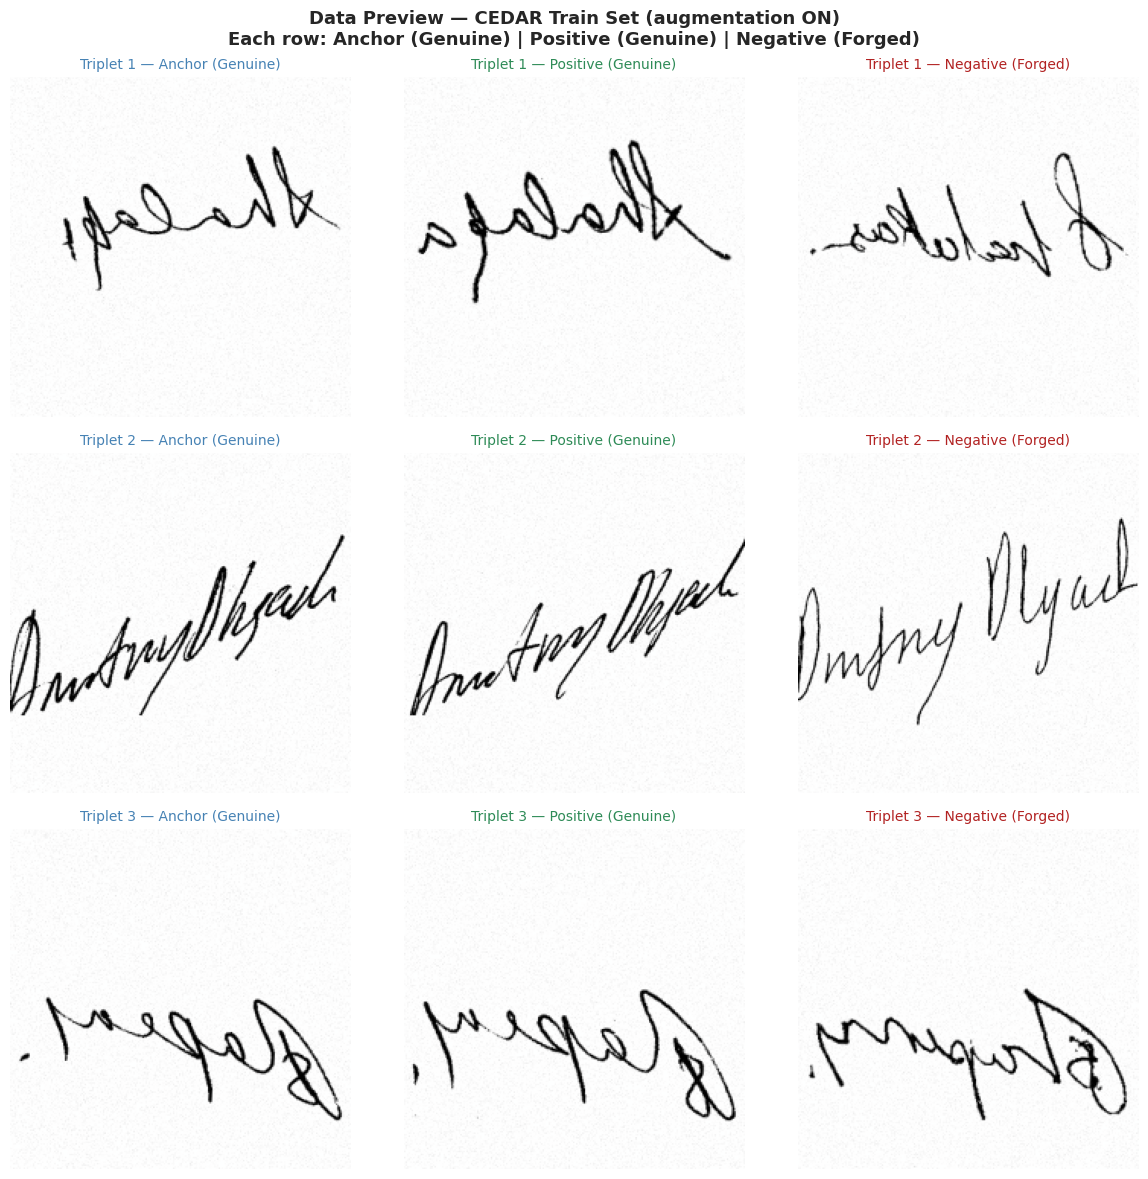

 > [Viz] Displayed 3 augmented triplets


In [5]:
def _unnorm(t):
    """Undo ImageNet normalisation for display. Returns H×W×C numpy in [0, 1]."""
    img  = t.cpu().numpy().transpose(1, 2, 0)          # C,H,W → H,W,C
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    return np.clip(std * img + mean, 0, 1)


# ── Preview: sample augmented triplets from first available split ─────────────
# Uses SplitTripletDataset with train_transform (augmentation ON) so the display
# shows exactly what Step 1 pretraining receives. Runs independently of the
# training loop — purely for pipeline verification before training starts.
_prev_data = None
for _r in SPLIT_RATIOS:
    _f = os.path.join(SPLIT_DIR, f"{DATASET}_split_{_r}.json")
    if os.path.exists(_f):
        with open(_f) as _fh:
            _prev_data = json.load(_fh)
        print(f" > [Viz] Preview using split '{_r}'")
        break

if _prev_data is None:
    print(" > [Viz] No split file found — run prepare_split_ratios.py first")
else:
    _ds      = SplitTripletDataset(_prev_data['train'], input_shape=INPUT_SHAPE, val_transform=val_transform, training=True)
    _loader  = DataLoader(_ds, batch_size=4, shuffle=True, num_workers=0)
    _a, _p, _n, _ = next(iter(_loader))

    N = min(3, _a.size(0))   # show up to 3 triplets
    fig, axes = plt.subplots(N, 3, figsize=(12, 4 * N))
    fig.suptitle(
        f"Data Preview — {DATASET_NAME} Train Set (augmentation ON)\n"
        "Each row: Anchor (Genuine) | Positive (Genuine) | Negative (Forged)",
        fontsize=13, fontweight='bold')

    if N == 1:                           # ensure 2-D indexing works for N=1
        axes = axes[np.newaxis, :]

    for i in range(N):
        for j, (tensor, title, color) in enumerate(zip(
                [_a[i], _p[i], _n[i]],
                ["Anchor (Genuine)", "Positive (Genuine)", "Negative (Forged)"],
                ['steelblue',        'seagreen',           'firebrick'])):
            axes[i, j].imshow(_unnorm(tensor))
            axes[i, j].set_title(f"Triplet {i+1} — {title}",
                                  fontsize=10, color=color)
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()
    print(f" > [Viz] Displayed {N} augmented triplets")


## Step 6 — Training Utilities

Contains all functions required for both training steps:

| Function | Role |
|---|---|
| `freeze_backbone` / `unfreeze_backbone` | Phase-transition helpers |
| `meta_train_epoch` | One episodic meta-training epoch |
| `meta_validate` | Episodic inference → `compute_metrics()` |
| `evaluate_model` | Thin wrapper: validate + optional plots |
| `run_pretraining` | Full Step 1 loop (two-phase, triplet loss) |
| `run_meta_training` | Full Step 2 loop (two-phase, differential LR) |

In [6]:
# ── Backbone freeze / unfreeze ────────────────────────────────────────────────
def freeze_backbone(fe):
    for p in fe.get_backbone_params():
        p.requires_grad = False

def unfreeze_backbone(fe):
    for p in fe.parameters():
        p.requires_grad = True

# ── One epoch of episodic meta-training ──────────────────────────────────────
def meta_train_epoch(fe, mg, loader, optimizer, criterion, device, scaler=None):
    fe.train();  mg.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch in tqdm(loader, desc="Meta-Train", leave=False):
        sup_imgs = batch['support_images'].squeeze(1).to(device)  # [B, C, H, W]
        qry_imgs = batch['query_images'].to(device)               # [B, N_Q, C, H, W]
        labels   = batch['query_labels'].to(device)               # [B, N_Q]

        B, N_Q, C, H, W = qry_imgs.shape
        qry_flat = qry_imgs.view(B * N_Q, C, H, W)
        lbl_flat = labels.view(B * N_Q).unsqueeze(1)
        
        optimizer.zero_grad()
        
        # Enable AMP for forward pass
        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            # 1. OPTIMIZATION: Extract support features ONCE
            sup_features_single = fe(sup_imgs) # [B, 1024]
            
            # 2. OPTIMIZATION: Expand the lightweight 1024-d features 
            # instead of duplicating the entire high-res image
            sup_features = sup_features_single.unsqueeze(1).expand(-1, N_Q, -1).reshape(B * N_Q, -1)
            
            # 3. Extract query features
            qry_features = fe(qry_flat)
            
            # 4. Metric Generator
            scores = mg(sup_features, qry_features)
            loss = criterion(scores, lbl_flat)
        
        # AMP Scaled Backward Pass
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        correct      += ((torch.sigmoid(scores) > 0.5).float() == lbl_flat).sum().item()
        total        += lbl_flat.size(0)

    return running_loss / len(loader), correct / total

# ── Episodic validation / inference ──────────────────────────────────────────
def meta_validate(fe, mg, loader, device):
    fe.eval();  mg.eval()
    all_labels, all_scores = [], []

    with torch.no_grad():
        for batch in loader:
            sup_imgs = batch['support_images'].squeeze(1).to(device)
            qry_imgs = batch['query_images'].to(device)
            labels   = batch['query_labels'].to(device)

            B, N_Q, C, H, W = qry_imgs.shape
            qry_flat = qry_imgs.view(B * N_Q, C, H, W)
            lbl_flat = labels.view(B * N_Q).unsqueeze(1)
            
            # OPTIMIZATION: Extract support ONCE and expand features
            sup_features_single = fe(sup_imgs)
            sup_features = sup_features_single.unsqueeze(1).expand(-1, N_Q, -1).reshape(B * N_Q, -1)
            
            qry_features = fe(qry_flat)
            
            probs = torch.sigmoid(mg(sup_features, qry_features))
            
            all_scores.extend(probs.cpu().numpy().flatten())
            all_labels.extend(lbl_flat.cpu().numpy().flatten())

    return compute_metrics(all_labels, all_scores)

def evaluate_model(fe, mg, loader, device, output_dir=None, silent=False):
    metrics = meta_validate(fe, mg, loader, device)

    if output_dir and not silent:
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        for k, fmt in [('eer',':.2%'),('auc',':.4f'),('threshold',':.4f'),
                       ('accuracy',':.2%'),('precision',':.2%'),
                       ('recall',':.2%'),('f1',':.2%')]:
            print(f"  {k.upper():<13}: {metrics.get(k, 0):{fmt[1:]}}")
        print("=" * 38)
        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)

    return metrics

# ── Step 1: Pretraining ───────────────────────────────────────────────────────
def run_pretraining(train_user_dict, device, checkpoint_path,
                    epochs=30, phase1_epochs=8, lr=1e-4,
                    margin=1.0, batch_size=32):
    print(f"\n   {'─'*56}")
    print(f"   STEP 1 — PRETRAINING  |  {epochs} epochs  "
          f"(P1 frozen: {phase1_epochs})")
    print(f"   LR: {lr}  |  Margin: {margin}  |  Batch: {batch_size}")
    print(f"   {'─'*56}")

    seed_everything(42)
    t0 = time.time()

    dataset   = SplitTripletDataset(train_user_dict, input_shape=INPUT_SHAPE, val_transform=val_transform, training=True)
    
    # OPTIMIZATION: Persistent workers
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
                           persistent_workers=(NUM_WORKERS > 0))
    
    model     = tDCBAM(backbone_name='densenet121',
                       output_dim=FEATURE_DIM, pretrained=True).to(device)
    criterion = TripletLoss(margin=margin, mode='euclidean')

    freeze_backbone(model.feature_extractor)
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"   Phase 1: {n_train:,} / {n_total:,} params trainable (backbone frozen)")

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = None
    best_loss = float('inf')
    
    # Init AMP Scaler
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        if epoch == phase1_epochs:
            unfreeze_backbone(model.feature_extractor)
            n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"   Phase 2: {n_train:,} params trainable (backbone unfrozen)")
            optimizer = optim.Adam(model.parameters(), lr=lr * 0.1)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                            optimizer, mode='min', factor=0.5, patience=5)

        model.train()
        epoch_loss = 0.0
        for anchor, pos, neg, _ in tqdm(loader, desc=f"Pretrain E{epoch+1:02d}", leave=False):
            anchor, pos, neg = anchor.to(device), pos.to(device), neg.to(device)
            optimizer.zero_grad()
            
            # AMP Forward Pass
            with torch.cuda.amp.autocast():
                loss = criterion(*model(anchor, pos, neg))
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        phase    = 1 if epoch < phase1_epochs else 2
        print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | "
              f"Active triplets: {criterion.last_fraction_active:.1%}")

        if scheduler is not None:
            scheduler.step(avg_loss)
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.feature_extractor.state_dict(), checkpoint_path)

        dataset._generate_triplets()

    print(f"   Pretraining done | Best loss: {best_loss:.4f} | "
          f"Time: {time.time() - t0:.1f}s")
    return checkpoint_path

# ── Step 2: Meta-training ─────────────────────────────────────────────────────
def run_meta_training(train_user_dict, val_user_dict, test_user_dict,
                      pretrained_path, device, checkpoint_path,
                      epochs=70, phase1_epochs=20,
                      lr_phase1=1e-3, lr_backbone=1e-5, lr_head=2e-4,
                      weight_decay=1e-2, batch_size=16, output_dir=None):
    print(f"\n   {'─'*56}")
    print(f"   STEP 2 — META-TRAINING  |  {epochs} epochs  "
          f"(P1 frozen: {phase1_epochs})")
    print(f"   LR P1: {lr_phase1}  |  backbone: {lr_backbone}  |  head: {lr_head}")
    print(f"   WD: {weight_decay}  |  Batch: {batch_size}")
    print(f"   {'─'*56}")

    t0 = time.time()

    train_set = SplitEpisodicDataset(
        train_user_dict,
        k_shot=K_SHOT, n_query_genuine=N_QUERY_GENUINE, n_query_forgery=N_QUERY_FORGERY,
        input_shape=INPUT_SHAPE, val_transform=val_transform,
        training=True,  exhaustive_eval=False
    )
    val_set = SplitEpisodicDataset(
        val_user_dict,
        k_shot=K_SHOT, n_query_genuine=N_QUERY_GENUINE, n_query_forgery=N_QUERY_FORGERY,
        input_shape=INPUT_SHAPE, val_transform=val_transform,
        # OPTIMIZATION: Force exhaustive evaluation for True Val EER
        training=False, exhaustive_eval=True 
    )
    test_set = SplitEpisodicDataset(
        test_user_dict,
        k_shot=K_SHOT, n_query_genuine=N_QUERY_GENUINE, n_query_forgery=N_QUERY_FORGERY,
        input_shape=INPUT_SHAPE, val_transform=val_transform,
        training=False, exhaustive_eval=True
    )

    # OPTIMIZATION: Persistent workers across all loaders
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                               num_workers=NUM_WORKERS, drop_last=True, persistent_workers=(NUM_WORKERS > 0))
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                               num_workers=NUM_WORKERS, drop_last=False, persistent_workers=(NUM_WORKERS > 0))
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                               num_workers=NUM_WORKERS, drop_last=False, persistent_workers=(NUM_WORKERS > 0))

    fe = DenseNetFeatureExtractor('densenet121', output_dim=FEATURE_DIM).to(device)
    mg = MetricGenerator(embedding_dim=EMBEDDING_DIM).to(device)

    if os.path.exists(pretrained_path):
        state = torch.load(pretrained_path, map_location=device, weights_only=False)
        try:
            fe.load_state_dict(state, strict=True)
            print("   Pretrained weights loaded (strict)")
        except RuntimeError as e:
            fe.load_state_dict(state, strict=False)
            print(f"   Pretrained weights loaded (partial — check keys): {e}")
    else:
        print(f"   WARNING: {pretrained_path} not found — ImageNet init only")

    criterion = nn.BCEWithLogitsLoss()
    best_eer, best_acc, best_metrics = 1.0, 0.0, {}

    def _save_ckpt(val_m):
        torch.save({
            'feature_extractor': fe.state_dict(),
            'metric_generator':  mg.state_dict(),
            'metrics': {k: float(v) for k, v in val_m.items()
                        if isinstance(v, (int, float, np.floating))}
        }, checkpoint_path)

    freeze_backbone(fe)
    n_train = sum(p.numel() for p in fe.parameters() if p.requires_grad)
    print(f"   Phase 1: {n_train:,} fe params trainable (backbone frozen)")

    optimizer = optim.AdamW([{'params': fe.get_head_params(), 'lr': lr_phase1},
                              {'params': mg.parameters(),      'lr': lr_phase1}],
                             weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=5)
    
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(phase1_epochs):
        tr_loss, tr_acc = meta_train_epoch(fe, mg, train_loader, optimizer, criterion, device, scaler=scaler)
        
        # OPTIMIZATION: Exhaustive Validation every 3 epochs or on the last epoch
        if (epoch + 1) % 3 == 0 or (epoch + 1) == phase1_epochs:
            val_m = meta_validate(fe, mg, val_loader, device)
            val_eer, val_acc = val_m['eer'], val_m['accuracy']
            print(f"   [P1] Epoch {epoch+1:02d}/{phase1_epochs} | Loss: {tr_loss:.4f} | Acc: {tr_acc:.2%} | Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
            
            scheduler.step(val_eer)
            if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
                best_eer, best_acc, best_metrics = val_eer, val_acc, val_m
                _save_ckpt(val_m)
                print(f"   >>> Checkpoint saved  (Val EER: {val_eer:.2%})")
        else:
            print(f"   [P1] Epoch {epoch+1:02d}/{phase1_epochs} | Loss: {tr_loss:.4f} | Acc: {tr_acc:.2%} | (Skipping Val)")


    unfreeze_backbone(fe)
    n_train = sum(p.numel() for p in fe.parameters() if p.requires_grad)
    print(f"   Phase 2: {n_train:,} fe params trainable (all unfrozen)")

    optimizer = optim.AdamW([{'params': fe.get_backbone_params(), 'lr': lr_backbone},
                              {'params': fe.get_head_params(),     'lr': lr_head},
                              {'params': mg.parameters(),          'lr': lr_head}],
                             weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=5)

    for epoch in range(epochs - phase1_epochs):
        tr_loss, tr_acc = meta_train_epoch(fe, mg, train_loader, optimizer, criterion, device, scaler=scaler)
        
        g_ep = phase1_epochs + epoch + 1
        
        # OPTIMIZATION: Exhaustive Validation every 3 epochs or on the last epoch
        if (epoch + 1) % 3 == 0 or (epoch + 1) == (epochs - phase1_epochs):
            val_m = meta_validate(fe, mg, val_loader, device)
            val_eer, val_acc = val_m['eer'], val_m['accuracy']
            
            print(f"   [P2] Epoch {epoch+1:02d}/{epochs - phase1_epochs} (G:{g_ep:02d}) | Loss: {tr_loss:.4f} | Acc: {tr_acc:.2%} | Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
            
            scheduler.step(val_eer)
            if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
                best_eer, best_acc, best_metrics = val_eer, val_acc, val_m
                _save_ckpt(val_m)
                print(f"   >>> Checkpoint saved  (Val EER: {val_eer:.2%})")
        else:
            print(f"   [P2] Epoch {epoch+1:02d}/{epochs - phase1_epochs} (G:{g_ep:02d}) | Loss: {tr_loss:.4f} | Acc: {tr_acc:.2%} | (Skipping Val)")

    if output_dir and os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        if isinstance(ckpt, dict) and 'feature_extractor' in ckpt:
            fe.load_state_dict(ckpt['feature_extractor'], strict=True)
            mg.load_state_dict(ckpt['metric_generator'],  strict=True)
            print("   Best checkpoint reloaded for final test evaluation")
        best_metrics = evaluate_model(fe, mg, test_loader, device,
                                       output_dir=output_dir, silent=False)

    print(f"   Meta-training done | Best Val EER: {best_eer:.2%} | Time: {time.time() - t0:.1f}s")
    return best_metrics

print(" > [Utils] All training functions defined")


 > [Utils] All training functions defined


## Step 7 — Run All Splits

In [7]:
all_results = {}
timing_log  = {}

for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    tr_p, va_p, te_p = ratio.split('_')
    split_label    = f"{tr_p}:{va_p}:{te_p}"
    split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{tr_p}-{va_p}-{te_p}")
    exp_dir        = os.path.join(CHECKPOINT_DIR, f"{DATASET}_{ratio}")
    os.makedirs(split_eval_dir, exist_ok=True)
    os.makedirs(exp_dir,        exist_ok=True)

    print(f"\n{'='*70}")
    print(f"  {DATASET_NAME}  —  {split_label}  Split")
    print(f"{'='*70}")

    if not os.path.exists(split_file):
        print(f"  SKIPPED: split file not found ({split_file})"); continue

    with open(split_file) as f:
        split_data = json.load(f)
    train_dict, val_dict, test_dict = (split_data['train'],
                                       split_data['val'],
                                       split_data['test'])
    print(f"  Writers — Train: {len(train_dict)} | Val: {len(val_dict)} | Test: {len(test_dict)}")

    # ── Step 1: Pretrain feature extractor ────────────────────────────────
    seed_everything(42)
    pretrain_path = os.path.join(exp_dir, "pretrained_backbone.pth")
    t0_pre = time.time()
    run_pretraining(train_dict, device=DEVICE, checkpoint_path=pretrain_path,
                    epochs=PRETRAIN_EPOCHS, phase1_epochs=PRETRAIN_PHASE1_EPOCHS,
                    lr=PRETRAIN_LR, margin=PRETRAIN_MARGIN,
                    batch_size=PRETRAIN_BATCH_SIZE)
    t_pre = time.time() - t0_pre

    # ── Step 2: Meta-train MetricGenerator ───────────────────────────────
    seed_everything(42)
    meta_ckpt = os.path.join(exp_dir, "best_meta_model.pth")
    t0_meta   = time.time()
    best_metrics = run_meta_training(
        train_dict, val_dict, test_dict,
        pretrained_path=pretrain_path, device=DEVICE,
        checkpoint_path=meta_ckpt,
        epochs=META_EPOCHS, phase1_epochs=META_PHASE1_EPOCHS,
        lr_phase1=META_LR_PHASE1, lr_backbone=META_LR_BACKBONE,
        lr_head=META_LR_HEAD, weight_decay=META_WEIGHT_DECAY,
        batch_size=META_BATCH_SIZE, output_dir=split_eval_dir)
    t_meta = time.time() - t0_meta

    # ── Record ────────────────────────────────────────────────────────────
    key = f"{DATASET_NAME} ({split_label})"
    all_results[key] = {
        'dataset':     DATASET_NAME,     'split':      split_label,
        'train_users': len(train_dict),  'val_users':  len(val_dict),
        'test_users':  len(test_dict),
        'eer':       float(best_metrics['eer']),
        'accuracy':  float(best_metrics['accuracy']),
        'auc':       float(best_metrics['auc']),
        'precision': float(best_metrics.get('precision', 0)),
        'recall':    float(best_metrics.get('recall',    0)),
        'f1':        float(best_metrics.get('f1',        0)),
    }
    timing_log[key] = {'pretrain_s': round(t_pre,  1),
                        'meta_s':    round(t_meta, 1),
                        'total_s':   round(t_pre + t_meta, 1)}

    print(f"  RESULT [{split_label}]: EER={best_metrics['eer']:.2%} | "
          f"Acc={best_metrics['accuracy']:.2%} | AUC={best_metrics['auc']:.4f} | "
          f"F1={best_metrics.get('f1',0):.4f} | Time={t_pre+t_meta:.1f}s")

print(f"\n{'='*70}\nALL EXPERIMENTS COMPLETE\n{'='*70}")



  CEDAR  —  70:15:15  Split
  Writers — Train: 38 | Val: 8 | Test: 9
 > [Seed] 42

   ────────────────────────────────────────────────────────
   STEP 1 — PRETRAINING  |  30 epochs  (P1 frozen: 0)
   LR: 0.0001  |  Margin: 0.2  |  Batch: 32
   ────────────────────────────────────────────────────────
 > [Seed] 42
   TripletDataset: 912 triplets | 38 users | triplet-level aug
   Phase 1: 1,658,248 / 8,612,104 params trainable (backbone frozen)
   Phase 2: 8,612,104 params trainable (backbone unfrozen)


/tmp/ipykernel_28206/3757961963.py:137: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Pretrain E01:   0%|          | 0/28 [00:00<?, ?it/s]

/tmp/ipykernel_28206/3757961963.py:155: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


   [P2] Epoch 01/30 | Loss: 0.1240 | Active triplets: 78.1%


...

Meta-Train:   0%|          | 0/2 [00:00<?, ?it/s]

   [P2] Epoch 49/50 (G:69) | Loss: 0.1548 | Acc: 95.31% | (Skipping Val)


/tmp/ipykernel_28206/3757961963.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):


Meta-Train:   0%|          | 0/2 [00:00<?, ?it/s]

   [P2] Epoch 50/50 (G:70) | Loss: 0.0849 | Acc: 98.44% | Val EER: 26.56% | Val Acc: 73.40%
   Best checkpoint reloaded for final test evaluation

========== FINAL TEST RESULTS ==========
  EER          : 23.61%
  AUC          : 0.8643
  THRESHOLD    : 0.1202
  ACCURACY     : 76.12%
  PRECISION    : 75.48%
  RECALL       : 75.85%
  F1           : 75.66%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/confusion_matrix.png
 > Saved DET Curve to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/det_curve.png
 > Saved FAR/FRR Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar

## Step 8 — Summary Table

In [8]:
W = 92
print(f"\n{'='*W}")
print(f"{'PROPOSED MODEL  —  ' + DATASET_NAME:^{W}}")
print(f"{'='*W}")
print(f"{'Split':<12} {'Train':>6} {'Val':>6} {'Test':>6}  "
      f"{'EER':>8} {'Accuracy':>9} {'AUC':>8} {'F1':>8}  "
      f"{'Pre(s)':>8} {'Meta(s)':>8} {'Total(s)':>9}")
print(f"{'-'*W}")
for key, res in all_results.items():
    t = timing_log.get(key, {})
    print(f"{res['split']:<12} {res['train_users']:>6} {res['val_users']:>6} "
          f"{res['test_users']:>6}  {res['eer']:>8.4f} {res['accuracy']:>9.4f} "
          f"{res['auc']:>8.4f} {res['f1']:>8.4f}  "
          f"{str(t.get('pretrain_s','—')):>8} {str(t.get('meta_s','—')):>8} "
          f"{str(t.get('total_s','—')):>9}")
print(f"{'='*W}")

results_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump({'results': all_results, 'timing': timing_log}, f, indent=2)
print(f"\n > Results saved → {results_path}")



                                  PROPOSED MODEL  —  CEDAR                                  
Split         Train    Val   Test       EER  Accuracy      AUC       F1    Pre(s)  Meta(s)  Total(s)
--------------------------------------------------------------------------------------------
70:15:15         38      8      9    0.2361    0.7612   0.8643   0.7566     142.1     69.2     211.3

 > Results saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_cedar_results.json


## Step 8 — Embedding Space Visualization (t-SNE)


Preparing data for t-SNE...
   EpisodicDataset: 9 users (K=1, Qg=1, Qf=1, no aug, exhaustive=True)
Loading Best Feature Extractor...
 > Extracting features for t-SNE visualization...
 > Running t-SNE dimensionality reduction on 423 signatures...


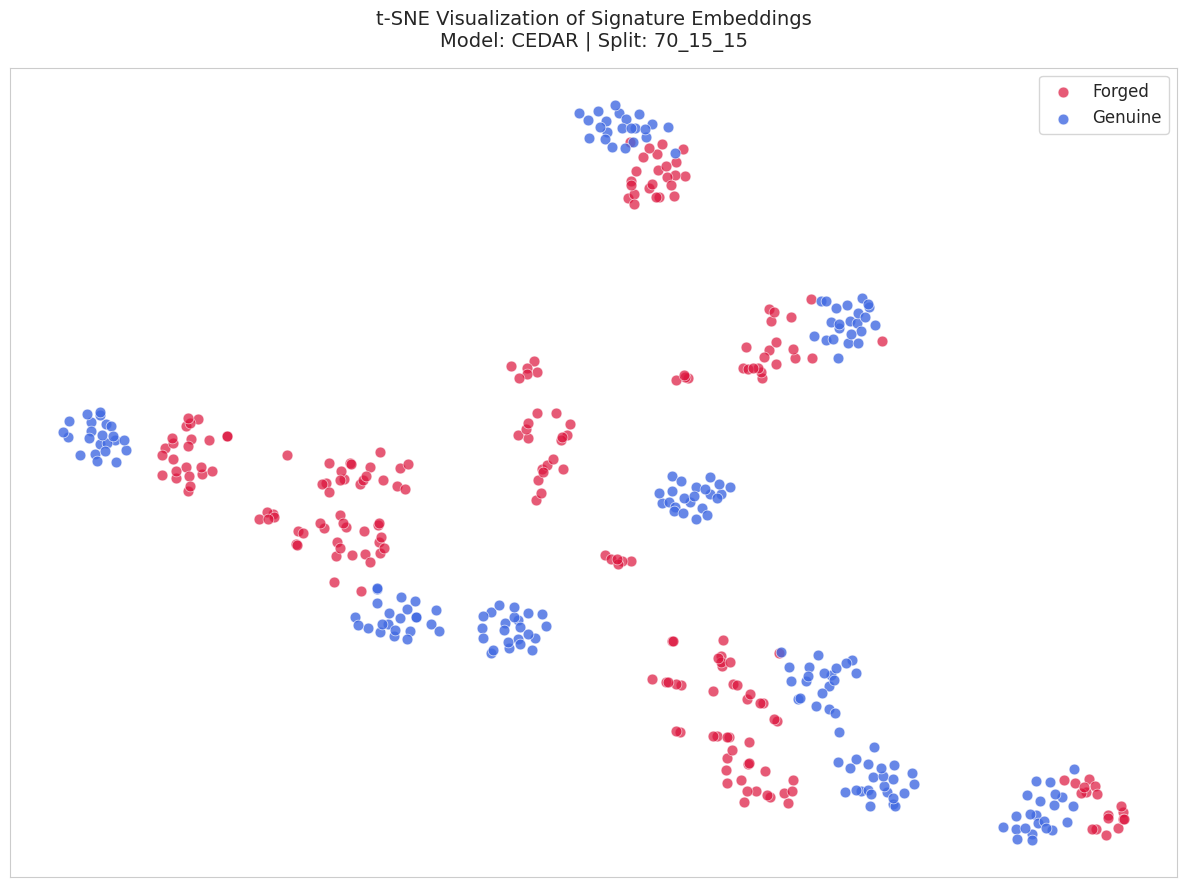

In [9]:
def visualize_embedding_space(feature_extractor, dataloader, device, num_batches=15):
    """
    Extracts 1024D embeddings from the DenseNet Feature Extractor and 
    compresses them to 2D using t-SNE to visualize cluster separation.
    """
    feature_extractor.eval()
    all_embeddings = []
    all_labels = []   # 1.0 for Genuine, 0.0 for Forged
    
    print(" > Extracting features for t-SNE visualization...")
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= num_batches: 
                break
                
            # We visualize the query images (which contain both genuine and forged)
            qry_imgs = batch['query_images'].to(device)       # [B, N_Q, C, H, W]
            labels = batch['query_labels'].to(device)         # [B, N_Q]
            
            # Flatten batch and query dimensions together
            B, N_Q, C, H, W = qry_imgs.shape
            qry_flat = qry_imgs.view(B * N_Q, C, H, W)
            lbl_flat = labels.view(B * N_Q).cpu().numpy()
            
            # Extract 1024D features from the backbone
            features = feature_extractor(qry_flat).cpu().numpy()
            
            all_embeddings.append(features)
            all_labels.append(lbl_flat)

    # Concatenate all collected data
    embeddings_np = np.vstack(all_embeddings)
    labels_np = np.concatenate(all_labels)

    print(f" > Running t-SNE dimensionality reduction on {embeddings_np.shape[0]} signatures...")
    
    # Compress 1024D -> 2D
    # Perplexity usually works best between 30 and 50 depending on batch size
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    embeddings_2d = tsne.fit_transform(embeddings_np)

    # Plotting
    plt.figure(figsize=(12, 9))
    
    # Plot Forgeries (Red) first so they sit in the background if overlapped
    plt.scatter(embeddings_2d[labels_np == 0, 0], embeddings_2d[labels_np == 0, 1], 
                c='crimson', label='Forged', alpha=0.7, edgecolors='white', s=60, linewidth=0.5)
    
    # Plot Genuine (Blue) on top
    plt.scatter(embeddings_2d[labels_np == 1, 0], embeddings_2d[labels_np == 1, 1], 
                c='royalblue', label='Genuine', alpha=0.8, edgecolors='white', s=60, linewidth=0.5)

    plt.title(f't-SNE Visualization of Signature Embeddings\nModel: {DATASET_NAME} | Split: {SPLIT_RATIOS[-1]}', fontsize=14, pad=15)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, linestyle='--', alpha=0.4)
    
    # Remove axis ticks for a cleaner plot
    plt.xticks([])
    plt.yticks([])
    
    plt.tight_layout()
    plt.show()

# ── Execution Block ───────────────────────────────────────────────────────────

# 1. Re-initialize the test dataloader using the last processed split data
print("\nPreparing data for t-SNE...")
tsne_test_set = SplitEpisodicDataset(
    test_dict, 
    k_shot=K_SHOT, 
    n_query_genuine=N_QUERY_GENUINE, 
    n_query_forgery=N_QUERY_FORGERY,
    input_shape=INPUT_SHAPE, 
    val_transform=val_transform,
    training=False, 
    exhaustive_eval=True # Ensures we get a wide variety of samples
)
tsne_test_loader = DataLoader(tsne_test_set, batch_size=META_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 2. Load the absolute best Feature Extractor from the checkpoint
print("Loading Best Feature Extractor...")
tsne_fe = DenseNetFeatureExtractor('densenet121', output_dim=FEATURE_DIM).to(DEVICE)
best_ckpt_path = os.path.join(exp_dir, "best_meta_model.pth")

if os.path.exists(best_ckpt_path):
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE, weights_only=False)
    tsne_fe.load_state_dict(ckpt['feature_extractor'], strict=True)
    
    # 3. Generate the visualization
    visualize_embedding_space(tsne_fe, tsne_test_loader, DEVICE, num_batches=20)
else:
    print(f"ERROR: Could not find checkpoint at {best_ckpt_path}")

## Step 10 — Results Chart

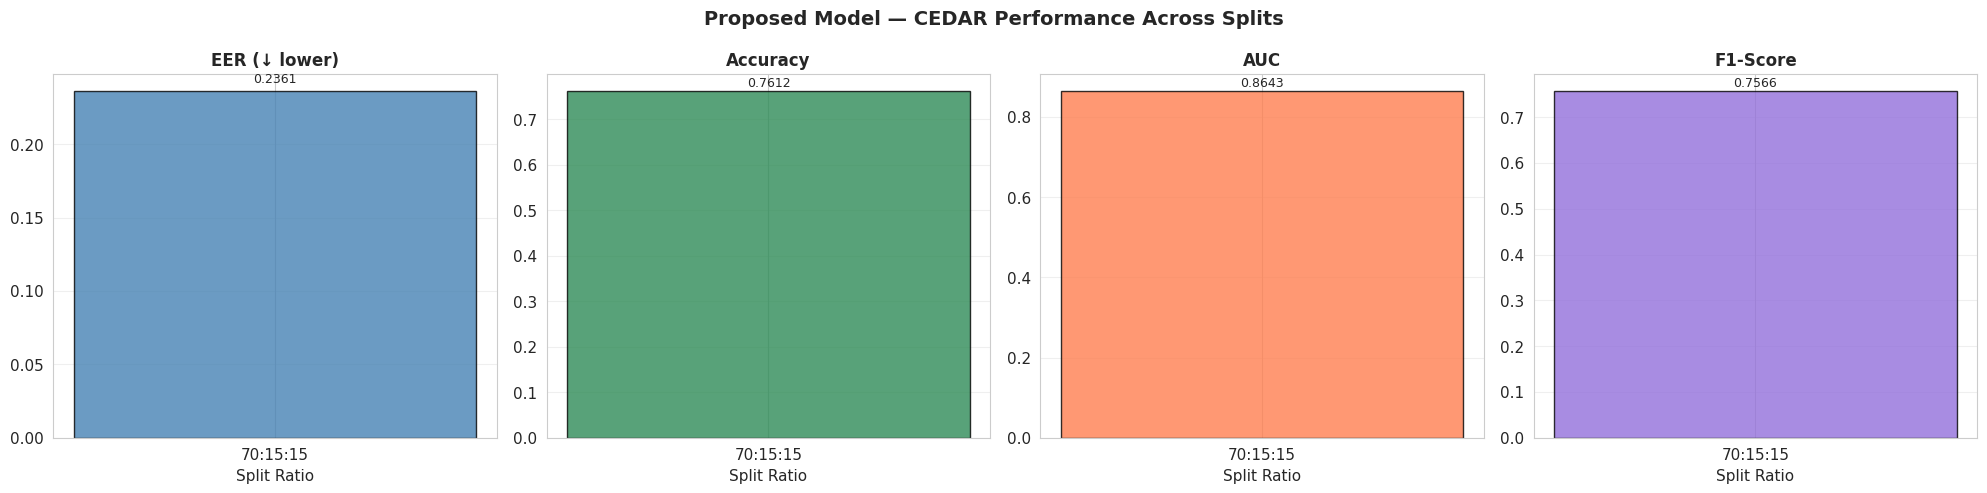

 > Plot saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_cedar_comparison.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Proposed Model — {DATASET_NAME} Performance Across Splits',
             fontsize=14, fontweight='bold')

for ax, metric, title, color in zip(
        axes,
        ['eer',           'accuracy',  'auc',   'f1'],
        ['EER (↓ lower)', 'Accuracy',  'AUC',   'F1-Score'],
        ['steelblue',     'seagreen',  'coral', 'mediumpurple']):

    split_labels = [r.replace('_', ':') for r in SPLIT_RATIOS]
    values = [all_results.get(f"{DATASET_NAME} ({r.replace('_',':')})", {}).get(metric, 0)
              for r in SPLIT_RATIOS]

    bars = ax.bar(split_labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved → {plot_path}")
